In [7]:
import requests
import pandas as pd
import time

params = {
    "query": "Ukraine",
    "mode": "ArtList",
    "maxrecords": 75,
    "format": "json",
    "startdatetime": "20240101000000",
    "enddatetime": "20240201000000",
    "sourcelang": "English"
}

print("Waiting 10 seconds before request...")
time.sleep(10)  # give it extra buffer on first try

response = requests.get(
    "https://api.gdeltproject.org/api/v2/doc/doc",
    params=params
)

print(f"Status: {response.status_code}")
print(response.text[:500])


Waiting 10 seconds before request...
Status: 429
Please limit requests to one every 5 seconds or contact kalev.leetaru5@gmail.com for larger queries.




                                                 url  \
0  http://www3.nhk.or.jp/news/html/20240204/k1001...   
1  https://www.15min.lt/naujiena/aktualu/pasaulis...   
2  https://www.wnp.pl/rynki-zagraniczne/ukraina-w...   
3  https://www.lokmat.com:443/international/big-n...   
4  https://runews24.ru/donetsk/13/02/2024/rossijs...   

                                          url_mobile  \
0                                                      
1                                                      
2                                                      
3  https://www.lokmat.com/international/big-news-...   
4  https://runews24.ru/amp/donetsk/13/02/2024/ros...   

                                               title          seendate  \
0       ロシア 一方的併合宣言の地域で  ウクライナ軍の攻撃受け28人死亡  と主張 | NHK  20240204T123000Z   
1  Dronais ir raketomis prieš laivus : svarbiausi...  20240201T143000Z   
2  Ukraina : Wywiad wojskowy : atak pod Moskwą to...  20240322T194500Z   
3  बुद्धिबळातील  चाणक्य  गॅरी 

<Axes: xlabel='datetime'>

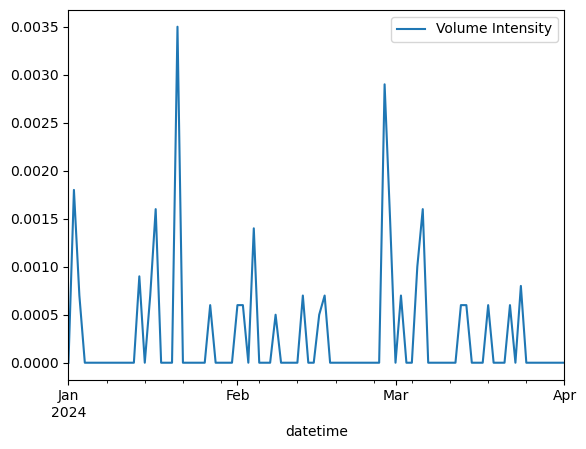

In [9]:
from gdeltdoc import GdeltDoc, Filters

f = Filters(
    keyword="Ukraine military attack",
    start_date="2024-01-01",
    end_date="2024-04-01"
)

gd = GdeltDoc()

# Article list
articles = gd.article_search(f)
print(articles.head())

# Timeline of volume
timeline = gd.timeline_search("timelinevol", f)
timeline.plot(x='datetime', y='Volume Intensity')

In [12]:
import requests
import time

time.sleep(5)

params = {
    "query": "Ukraine attack",
    "mode": "pointdata",
    "format": "geojson",
    "timespan": "7d",
    "maxpoints": 1000,
    "geore": 2
}

response = requests.get(
    "https://api.gdeltproject.org/api/v2/geo/geo",
    params=params
)

# Print the full URL that was actually sent
print("URL sent:", response.url)
print("Status:", response.status_code)
print("Response text:", response.text[:500])



URL sent: https://api.gdeltproject.org/api/v2/geo/geo?query=Ukraine+attack&mode=pointdata&format=geojson&timespan=7d&maxpoints=1000&geore=2
Status: 404
Response text: <!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 4.01//EN" "http://www.w3.org/TR/html4/strict.dtd">
<html><head>
<title>404 Not Found</title>
</head><body>
<h1>Not Found</h1>
<p>The requested URL was not found on this server.</p>
</body></html>



In [28]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import requests
import time

# GDELT 2.0 event file - one day of data
# Column 53 and 54 are ActionGeo_Lat and ActionGeo_Long
url = "http://data.gdeltproject.org/gdeltv2/20240301000000.export.CSV.zip"

print("Downloading GDELT event file...")
df = pd.read_csv(
    url,
    compression='zip',
    sep='\t',
    header=None,
    on_bad_lines='skip'
)

print(f"Columns: {len(df.columns)}")
print(f"Rows: {len(df)}")
print(df.head(2))

Columns: 61
Rows: 3779
           0         1       2     3          4    5    6    7    8    9   \
0  1160987682  20230302  202303  2023  2023.1699  NaN  NaN  NaN  NaN  NaN   
1  1160987683  20230302  202303  2023  2023.1699  NaN  NaN  NaN  NaN  NaN   

   ... 51                                               52  53    54     55  \
0  ...  3  Wesleyan University, Connecticut, United States  US  USCT    NaN   
1  ...  4      Northern Ireland, Craigavon, United Kingdom  UK  UKR8  40152   

        56       57        58              59  \
0  41.5557 -72.6556    211915  20240301000000   
1  54.5000  -6.5000  -2604275  20240301000000   

                                                  60  
0  http://www.theridgefieldpress.com/news/educati...  
1  https://www.peeblesshirenews.com/news/national...  

[2 rows x 61 columns]


In [49]:
from io import BytesIO
import pandas as pd
import requests
import time

name_mapping = pd.read_csv("/Users/kenhartman/Documents/osint/gdelt_column_names_v2.csv", header=None).iloc[:, 0].tolist()
# Build list of 15-minute file timestamps for one full day
# Format: YYYYMMDDHHMMSS — files run every 15 min
date = "20240301"
hours = range(0, 24)
minutes = [0, 15, 30, 45]

urls = []
for h in hours:
    for m in minutes:
        timestamp = f"{date}{h:02d}{m:02d}00"
        url = f"http://data.gdeltproject.org/gdeltv2/{timestamp}.export.CSV.zip"
        urls.append(url)

print(f"Files to download: {len(urls)}")

# Download and filter on the fly — don't store everything
frames = []
for i, url in enumerate(urls):
    try:
        time.sleep(0.5)  # be polite
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            chunk = pd.read_csv(
                BytesIO(response.content),
                compression='zip',
                sep='\t',
                header=None,
                names=name_mapping,
                on_bad_lines='skip'
            )
            # Filter immediately to keep memory low
            filtered = chunk[
                (chunk['ActionGeo_CountryCode'] == 'UP') &
                (chunk['EventRootCode'].isin([18, 19, 20])) &
                (chunk['ActionGeo_Lat'].notna()) &
                (chunk['ActionGeo_Long'].notna())
            ]
            if len(filtered) > 0:
                frames.append(filtered)
            print(f"[{i+1}/96] {url.split('/')[-1]} — {len(filtered)} Ukraine conflict events")
        else:
            print(f"[{i+1}/96] SKIP {response.status_code}")
    except Exception as e:
        print(f"[{i+1}/96] ERROR: {e}")

# Combine all
if frames:
    ukraine_full = pd.concat(frames, ignore_index=True)
    print(f"\nTotal Ukraine conflict events for {date}: {len(ukraine_full)}")
else:
    print("No events found")


Files to download: 96
[1/96] 20240301000000.export.CSV.zip — 2 Ukraine conflict events
[2/96] 20240301001500.export.CSV.zip — 3 Ukraine conflict events
[3/96] 20240301003000.export.CSV.zip — 2 Ukraine conflict events
[4/96] 20240301004500.export.CSV.zip — 16 Ukraine conflict events
[5/96] 20240301010000.export.CSV.zip — 10 Ukraine conflict events
[6/96] 20240301011500.export.CSV.zip — 1 Ukraine conflict events
[7/96] 20240301013000.export.CSV.zip — 5 Ukraine conflict events
[8/96] 20240301014500.export.CSV.zip — 1 Ukraine conflict events
[9/96] 20240301020000.export.CSV.zip — 0 Ukraine conflict events
[10/96] 20240301021500.export.CSV.zip — 0 Ukraine conflict events
[11/96] 20240301023000.export.CSV.zip — 3 Ukraine conflict events
[12/96] 20240301024500.export.CSV.zip — 2 Ukraine conflict events
[13/96] 20240301030000.export.CSV.zip — 20 Ukraine conflict events
[14/96] 20240301031500.export.CSV.zip — 2 Ukraine conflict events
[15/96] 20240301033000.export.CSV.zip — 1 Ukraine conflict e

In [50]:
ukraine_full

,GlobalEventID,Day,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,...,ActionGeo_Type,ActionGeo_Fullname,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_ADM2Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL
0,1160990477,20240301,202403,2024,2024.1671,UKR,UKRAINIAN,UKR,NaN,NaN,...,1,Ukraine,UP,UP,NaN,49.0000,32.0000,UP,20240301000000,https://www.forbes.com/sites/davidaxe/2024/02/...
1,1160990505,20240301,202403,2024,2024.1671,UKRMIL,UKRAINIAN,UKR,NaN,NaN,...,1,Ukraine,UP,UP,NaN,49.0000,32.0000,UP,20240301000000,https://www.forbes.com/sites/davidaxe/2024/02/...
2,1160992553,20240301,202403,2024,2024.1671,NaN,NaN,NaN,NaN,NaN,...,1,Ukraine,UP,UP,NaN,49.0000,32.0000,UP,20240301001500,https://learningenglish.voanews.com/a/us-army-...
3,1160992724,20240301,202403,2024,2024.1671,AFGINSTAL,TALIBAN,AFG,TAL,NaN,...,1,Ukraine,UP,UP,NaN,49.0000,32.0000,UP,20240301001500,https://learningenglish.voanews.com/a/us-army-...
4,1160994085,20240301,202403,2024,2024.1671,MIL,ARMY,NaN,NaN,NaN,...,1,Ukraine,UP,UP,NaN,49.0000,32.0000,UP,20240301001500,https://learningenglish.voanews.com/a/us-army-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,1161214103,20240301,202403,2024,2024.1671,UKRGOVMIL,UKRAINE,UKR,NaN,NaN,...,4,"Melitopol, Zaporiz'ka Oblast', Ukraine",UP,UP26,28566,46.8489,35.3653,-1046418,20240301231500,https://leadership.ng/russias-armed-aggression...
372,1161214104,20240301,202403,2024,2024.1671,UKRGOVMIL,UKRAINE,UKR,NaN,NaN,...,4,"Dnipro, Ukraine (general), Ukraine",UP,UP00,28557,46.4975,32.3086,-2902197,20240301231500,https://leadership.ng/russias-armed-aggression...
373,1161214108,20240301,202403,2024,2024.1671,UKRGOVMIL,UKRAINE,UKR,NaN,NaN,...,4,"Dnipro, Ukraine (general), Ukraine",UP,UP00,28557,46.4975,32.3086,-2902197,20240301231500,https://leadership.ng/russias-armed-aggression...
374,1161214109,20240301,202403,2024,2024.1671,UKRGOVMIL,UKRAINE,UKR,NaN,NaN,...,4,"Dnipro, Ukraine (general), Ukraine",UP,UP00,28557,46.4975,32.3086,-2902197,20240301231500,https://leadership.ng/russias-armed-aggression...


In [48]:
name_mapping = pd.read_csv("/Users/kenhartman/Documents/osint/gdelt_column_names_v2.csv", header=None)
print(name_mapping.head())
df.columns = name_mapping[0].values

               0
0  GlobalEventID
1            Day
2      MonthYear
3           Year
4   FractionDate


In [45]:
ukraine_events = df[
    (df['ActionGeo_CountryCode'] == 'UP') &
    (df['EventRootCode'].isin([18, 19, 20])) &
    (df['ActionGeo_Lat'].notna()) &
    (df['ActionGeo_Long'].notna())
].copy()

print(f"Ukraine conflict events: {len(ukraine_events)}")

Ukraine conflict events: 2


In [43]:
# Check what country codes actually exist in the file
print("All country codes in file:")
print(df['ActionGeo_CountryCode'].value_counts().head(20))

# Check what event root codes exist
print("\nAll event root codes:")
print(df['EventRootCode'].value_counts().head(20))
print(f"data types: {df['EventRootCode'].dtype}")

# Check how many Ukraine rows exist regardless of event code
print("\nAll Ukraine rows:")
print(len(df[df['ActionGeo_CountryCode'] == 'UP']))

# Check a sample of raw values to spot encoding issues
print("\nSample ActionGeo_CountryCode values:")
print(df['ActionGeo_CountryCode'].head(20).tolist())

All country codes in file:
ActionGeo_CountryCode
US    1791
IS     381
AS     143
CA     109
RS     105
UK      84
UP      71
CH      70
QA      54
FR      41
JO      38
CU      34
MX      33
IN      32
NI      29
GH      28
EG      26
NZ      24
BD      23
TH      20
Name: count, dtype: int64

All event root codes:
EventRootCode
4     927
1     569
2     337
19    279
11    246
5     243
3     222
17    171
7     166
12    121
8     106
9      95
13     83
6      57
18     55
16     36
10     29
14     22
15     11
20      4
Name: count, dtype: int64
data types: int64

All Ukraine rows:
71

Sample ActionGeo_CountryCode values:
['US', 'UK', 'PK', 'PK', 'SW', 'US', 'US', 'US', 'US', 'US', 'US', 'CA', 'US', 'US', 'AS', 'AS', 'HA', 'HA', 'HA', 'ID']


In [5]:
gedevent = pd.read_csv("/Users/kenhartman/Documents/osint/GEDEvent_v25_1.csv")
print(gedevent.head())

/var/folders/z5/dzs2wvw11fl5s571q4b97thh0000gn/T/ipykernel_68279/1702349174.py:1: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  gedevent = pd.read_csv("/Users/kenhartman/Documents/osint/GEDEvent_v25_1.csv")


       id               relid  year  active_year code_status  \
0  244657  IRQ-2017-1-524-322  2017         True       Clear   
1  412700  IRQ-2021-1-524-145  2021         True       Clear   
2  413023  IRQ-2021-1-524-143  2021         True       Clear   
3  412909  IRQ-2021-1-524-144  2021         True       Clear   
4  132140    AFG-1989-1-411-2  1989         True       Clear   

   type_of_violence  conflict_dset_id  conflict_new_id  \
0                 1               259              259   
1                 1               259              259   
2                 1               259              259   
3                 1               259              259   
4                 1               333              333   

             conflict_name  dyad_dset_id  ...                 date_end  \
0         Iraq: Government           524  ...  2017-07-31 00:00:00.000   
1         Iraq: Government           524  ...  2021-08-26 00:00:00.000   
2         Iraq: Government           524  ..

In [6]:
ukraine_gedevent = gedevent[gedevent['country']=='Ukraine']
print(ukraine_gedevent.head())

            id              relid  year  active_year code_status  \
347094  449376  UKR-2022-3-920-61  2022         True       Clear   
347095  448644  UKR-2022-3-920-58  2022         True       Clear   
347096  449504  UKR-2022-3-920-93  2022         True       Clear   
347097  441013  RUS-2022-3-920-86  2022         True       Clear   
347098  437626  RUS-2022-3-920-68  2022         True       Clear   

        type_of_violence  conflict_dset_id  conflict_new_id  \
347094                 3                57              453   
347095                 3                57              453   
347096                 3                57              453   
347097                 3                57              453   
347098                 3                57              453   

                                          conflict_name  dyad_dset_id  ...  \
347094  Government of Russia (Soviet Union) - Civilians            57  ...   
347095  Government of Russia (Soviet Union) - Civilians 

In [7]:
ukraine_gedevent.to_csv("/Users/kenhartman/Documents/osint/ukraine_gedevent.csv", index=False)

In [9]:
import os
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '/Users/kenhartman/.config/gcloud/application_default_credentials.json'

from google.cloud import bigquery
client = bigquery.Client(project='gdelt-reader')
print(f"Project: {client.project}")


Project: gdelt-reader


/opt/anaconda3/envs/gds/lib/python3.12/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [2]:
from google.cloud import bigquery

client = bigquery.Client(
    project='gdelt-reader',
    location='US'
)

/opt/anaconda3/envs/gds/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.3) or chardet (7.4.0.post2)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(
/opt/anaconda3/envs/gds/lib/python3.12/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [11]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project='gdelt-reader-492021', location='US')

print(f"Project: {client.project}")

# First find the most recent date in the table
date_query = """
SELECT MAX(SQLDATE) as latest_date
FROM `gdelt-bq.gdeltv2.events`
"""

latest = client.query(date_query).to_dataframe()
latest_date = latest['latest_date'].iloc[0]
print(f"Most recent date in GDELT: {latest_date}")

/opt/anaconda3/envs/gds/lib/python3.12/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Project: gdelt-reader-492021
Most recent date in GDELT: 20260402


In [16]:


# Now pull Ukraine conflict events for that date
query = f"""
SELECT *
FROM `gdelt-bq.gdeltv2.events`
WHERE SQLDATE = {latest_date}
    AND ActionGeo_CountryCode = 'UP'
    AND EventRootCode IN ('18', '19', '20')
    AND ActionGeo_Lat IS NOT NULL
    AND ActionGeo_Long IS NOT NULL
"""

df = client.query(query).to_dataframe()
print(f"Ukraine conflict events: {len(df)}")
print(df.head())

Ukraine conflict events: 21
   GLOBALEVENTID   SQLDATE  MonthYear  Year  FractionDate Actor1Code  \
0     1297258771  20260402     202604  2026     2026.2521        UKR   
1     1297258770  20260402     202604  2026     2026.2521        UKR   
2     1297259115  20260402     202604  2026     2026.2521        JUD   
3     1297259227  20260402     202604  2026     2026.2521        UKR   
4     1297259120  20260402     202604  2026     2026.2521        JUD   

   Actor1Name Actor1CountryCode Actor1KnownGroupCode Actor1EthnicCode  ...  \
0     KHARKIV               UKR                 None             None  ...   
1      ODESSA               UKR                 None             None  ...   
2  PROSECUTOR              None                 None             None  ...   
3     UKRAINE               UKR                 None             None  ...   
4  PROSECUTOR              None                 None             None  ...   

  ActionGeo_Type                            ActionGeo_FullName  \
0   

In [17]:
df.to_csv("/Users/kenhartman/Documents/osint/ukraine_gdelt_20260402.csv", index=False)

In [4]:
import pandas as pd
df = pd.read_csv("/Users/kenhartman/Documents/osint/ukraine_gdelt_20260402.csv")
print(df.columns)

Index(['GLOBALEVENTID', 'SQLDATE', 'MonthYear', 'Year', 'FractionDate',
       'Actor1Code', 'Actor1Name', 'Actor1CountryCode', 'Actor1KnownGroupCode',
       'Actor1EthnicCode', 'Actor1Religion1Code', 'Actor1Religion2Code',
       'Actor1Type1Code', 'Actor1Type2Code', 'Actor1Type3Code', 'Actor2Code',
       'Actor2Name', 'Actor2CountryCode', 'Actor2KnownGroupCode',
       'Actor2EthnicCode', 'Actor2Religion1Code', 'Actor2Religion2Code',
       'Actor2Type1Code', 'Actor2Type2Code', 'Actor2Type3Code', 'IsRootEvent',
       'EventCode', 'EventBaseCode', 'EventRootCode', 'QuadClass',
       'GoldsteinScale', 'NumMentions', 'NumSources', 'NumArticles', 'AvgTone',
       'Actor1Geo_Type', 'Actor1Geo_FullName', 'Actor1Geo_CountryCode',
       'Actor1Geo_ADM1Code', 'Actor1Geo_ADM2Code', 'Actor1Geo_Lat',
       'Actor1Geo_Long', 'Actor1Geo_FeatureID', 'Actor2Geo_Type',
       'Actor2Geo_FullName', 'Actor2Geo_CountryCode', 'Actor2Geo_ADM1Code',
       'Actor2Geo_ADM2Code', 'Actor2Geo_Lat', 'Act

In [15]:
table = client.get_table("gdelt-bq.gdeltv2.events")
for field in table.schema:
    print(f"{field.name} — {field.field_type}")

GLOBALEVENTID — INTEGER
SQLDATE — INTEGER
MonthYear — INTEGER
Year — INTEGER
FractionDate — FLOAT
Actor1Code — STRING
Actor1Name — STRING
Actor1CountryCode — STRING
Actor1KnownGroupCode — STRING
Actor1EthnicCode — STRING
Actor1Religion1Code — STRING
Actor1Religion2Code — STRING
Actor1Type1Code — STRING
Actor1Type2Code — STRING
Actor1Type3Code — STRING
Actor2Code — STRING
Actor2Name — STRING
Actor2CountryCode — STRING
Actor2KnownGroupCode — STRING
Actor2EthnicCode — STRING
Actor2Religion1Code — STRING
Actor2Religion2Code — STRING
Actor2Type1Code — STRING
Actor2Type2Code — STRING
Actor2Type3Code — STRING
IsRootEvent — INTEGER
EventCode — STRING
EventBaseCode — STRING
EventRootCode — STRING
QuadClass — INTEGER
GoldsteinScale — FLOAT
NumMentions — INTEGER
NumSources — INTEGER
NumArticles — INTEGER
AvgTone — FLOAT
Actor1Geo_Type — INTEGER
Actor1Geo_FullName — STRING
Actor1Geo_CountryCode — STRING
Actor1Geo_ADM1Code — STRING
Actor1Geo_ADM2Code — STRING
Actor1Geo_Lat — FLOAT
Actor1Geo_Long — 

In [5]:
print(f"Project: {client.project}")

# Check if the GDELT table is accessible
table_ref = client.get_table("gdelt-bq.gdeltv2.events")
print(f"Table: {table_ref.full_table_id}")
print(f"Rows: {table_ref.num_rows:,}")
print(f"Columns: {len(table_ref.schema)}")

Project: gdelt-reader
Table: gdelt-bq:gdeltv2.events
Rows: 885,793,282
Columns: 61


In [20]:
import requests
from bs4 import BeautifulSoup
import time
import json
from datetime import datetime, timezone

# High value channels from the list
CHANNELS = [
    'GeneralStaffZSU',      # Official General Staff
    'landforcesofukraine',  # Ground Forces official
    'SBUkr',                # Security Service of Ukraine
    'ukr_sof',              # Special Operations Forces
    'ua_dshv',              # Air Assault Forces
    'HolodniyYar_93ombr',   # 93rd Mechanized Brigade
    'brigada92_war',        # 92nd Assault Brigade
    'brigade95',            # 95th Air Assault Brigade
    'azov_media',           # 12th Special Purpose Brigade
    'ab3army',              # 3rd Assault Brigade
]

def scrape_telegram_channel(channel, limit=10):
    url = f"https://t.me/s/{channel}"
    headers = {'User-Agent': 'Mozilla/5.0'}

    try:
        response = requests.get(url, headers=headers, timeout=10)
        if response.status_code != 200:
            return []

        soup = BeautifulSoup(response.text, 'html.parser')
        messages = []
        seen_texts = set()

        for post in soup.find_all('div', class_='tgme_widget_message'):
            text_div = post.find('div', class_='tgme_widget_message_text')
            text = text_div.get_text(strip=True) if text_div else ''

            if not text or text in seen_texts:
                continue
            seen_texts.add(text)

            date_tag = post.find('time')
            date = date_tag.get('datetime', '') if date_tag else ''

            link_tag = post.find('a', class_='tgme_widget_message_date')
            msg_url = link_tag.get('href', '') if link_tag else ''

            views_tag = post.find('span', class_='tgme_widget_message_views')
            views = views_tag.get_text(strip=True) if views_tag else '0'

            messages.append({
                'channel': channel,
                'text': text[:500],  # cap at 500 chars
                'date': date,
                'url': msg_url,
                'views': views,
                'scraped_at': datetime.now(timezone.utc).isoformat()
            })

        return messages[:limit]

    except Exception as e:
        print(f"  ERROR: {e}")
        return []

# Run scraper
all_messages = []
for channel in CHANNELS:
    print(f"Scraping {channel}...")
    msgs = scrape_telegram_channel(channel)
    all_messages.extend(msgs)
    print(f"  {len(msgs)} messages")
    time.sleep(2)  # be polite

# Save to JSON
output = {
    'generated': datetime.now(timezone.utc).isoformat(),
    'total': len(all_messages),
    'channels_scraped': len(CHANNELS),
    'messages': all_messages
}

with open('telegram_osint.json', 'w', encoding='utf-8') as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

print(f"\nTotal messages: {len(all_messages)}")
print(f"Saved to telegram_osint.json")
print(json.dumps(all_messages[:2], indent=2, ensure_ascii=False))

Scraping GeneralStaffZSU...
  7 messages
Scraping landforcesofukraine...
  7 messages
Scraping SBUkr...
  10 messages
Scraping ukr_sof...
  10 messages
Scraping ua_dshv...
  10 messages
Scraping HolodniyYar_93ombr...
  5 messages
Scraping brigada92_war...
  4 messages
Scraping brigade95...
  4 messages
Scraping azov_media...
  3 messages
Scraping ab3army...
  9 messages

Total messages: 69
Saved to telegram_osint.json
[
  {
    "channel": "GeneralStaffZSU",
    "text": "⚡️Генеральним штабом ЗС України спрощено повернення військовослужбовців після самовільного залишення військової частини.Головнокомандувач ЗС України виключив проміжні ланки в опрацюванні документів, зокрема армійський корпус, оперативне командування, вид тощо.Документи на призначення тепер подаються напряму від військової частини до Генерального штабу ЗС України.Ці кроки покликані пришвидшити призначення військовослужбовців на посади, зробити процес їх переведення прозорішим та усунути маніпуляц",
    "date": "2026-04-0

In [1]:
from mordecai3 import Geoparser

geo = Geoparser()

# Test with a Ukraine conflict sentence
result = geo.geoparse_doc("Russian forces attacked Kharkiv and Kramatorsk with drone strikes.")
print(result)

/opt/anaconda3/envs/gds/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.3) or chardet (7.4.0.post2)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


{'doc_text': 'Russian forces attacked Kharkiv and Kramatorsk with drone strikes.', 'event_location_raw': '', 'geolocated_ents': [{'feature_code': 'PPLA', 'feature_class': 'P', 'country_code3': 'UKR', 'lat': 49.98177, 'lon': 36.25475, 'name': 'Kharkiv', 'admin1_code': '07', 'admin1_name': 'Kharkivs’ka Oblast’', 'admin2_code': '6312', 'admin2_name': 'Kharkiv Raion', 'geonameid': '706483', 'score': 1.0, 'search_name': 'Kharkiv', 'start_char': 24, 'end_char': 31, 'city_id': '706483', 'city_name': 'Kharkiv'}, {'feature_code': 'PPLA2', 'feature_class': 'P', 'country_code3': 'UKR', 'lat': 48.73049, 'lon': 37.58793, 'name': 'Kramatorsk', 'admin1_code': '05', 'admin1_name': 'Donetsk', 'admin2_code': '1412', 'admin2_name': 'Kramatorskyi Raion', 'geonameid': '704508', 'score': 1.0, 'search_name': 'Kramatorsk', 'start_char': 36, 'end_char': 46, 'city_id': '704508', 'city_name': 'Kramatorsk'}]}


In [2]:
from mordecai3 import Geoparser
from deep_translator import GoogleTranslator
import json
import time

# Load your telegram data
with open('telegram_osint.json', 'r') as f:
    telegram_data = json.load(f)

geo = Geoparser()
translator = GoogleTranslator(source='uk', target='en')

geolocated_messages = []

for msg in telegram_data['messages'][:20]:  # test on first 20
    try:
        # Translate Ukrainian to English
        translated = translator.translate(msg['text'])
        print(f"\nChannel: {msg['channel']}")
        print(f"Translated: {translated[:100]}...")

        # Geoparse the translated text
        result = geo.geoparse_doc(translated)
        locations = result.get('geolocated_ents', [])

        if locations:
            for loc in locations:
                geolocated_messages.append({
                    'channel': msg['channel'],
                    'original_text': msg['text'][:200],
                    'translated_text': translated[:200],
                    'date': msg['date'],
                    'url': msg['url'],
                    'views': msg['views'],
                    'place_name': loc['name'],
                    'lat': loc['lat'],
                    'lon': loc['lon'],
                    'country': loc['country_code3'],
                    'admin1': loc['admin1_name'],
                    'score': loc['score']
                })
            print(f"  Found {len(locations)} locations: {[l['name'] for l in locations]}")
        else:
            print(f"  No locations found")

        time.sleep(0.5)  # be gentle with translator

    except Exception as e:
        print(f"  ERROR: {e}")

print(f"\nTotal geolocated messages: {len(geolocated_messages)}")
print(json.dumps(geolocated_messages[:2], indent=2))


Channel: GeneralStaffZSU
Translated: ⚡️The General Staff of the Armed Forces of Ukraine simplified the return of servicemen after volunta...
  No locations found

Channel: GeneralStaffZSU
Translated: Battle for Kyiv. April 2, 2022 is a date that will forever go down in history as the day of complete...
  Found 4 locations: ['Kyiv', 'Kyiv', 'Kyiv', 'Kyiv']

Channel: GeneralStaffZSU
Translated: Since the beginning of 2026, engineering units of the Support Forces of the Armed Forces of Ukraine ...
  No locations found

Channel: GeneralStaffZSU
Translated: "Today is the fourth anniversary of the end of the battle for Kyiv and the liberation of the Kyiv re...
  Found 2 locations: ['Kyiv', 'Kyiv']

Channel: GeneralStaffZSU
Translated: Operational information as of 4:00 p.m. 04/02/2026 regarding the Russian invasion. Since the beginni...
  Found 15 locations: ['Sumska Oblast', 'Bachivsk', 'Iskryskivshchyna', 'Bezsalivka', 'Tovstodubove', 'Vyntorivka', 'Volfyne', 'Korenok', 'Prohres', 'Brusky

In [5]:
import json
from datetime import datetime, timezone

# Deduplicate — same message can mention same place multiple times
seen = set()
unique_locations = []
for loc in geolocated_messages:
    key = f"{loc['channel']}_{loc['url']}_{loc['place_name']}"
    if key not in seen:
        seen.add(key)
        unique_locations.append(loc)

print(f"Unique geolocated mentions: {len(unique_locations)}")

# Filter to Ukraine only
ukraine_locations = [l for l in unique_locations if l['country'] == 'UKR']
print(f"Ukraine locations only: {len(ukraine_locations)}")

# Save
output = {
    'generated': datetime.now(timezone.utc).isoformat(),
    'total': len(ukraine_locations),
    'source': 'Telegram OSINT — Official Ukrainian Military Channels',
    'locations': ukraine_locations
}

with open('telegram_geolocated.json', 'w', encoding='utf-8') as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

print("Saved to telegram_geolocated.json")

Unique geolocated mentions: 40
Ukraine locations only: 35
Saved to telegram_geolocated.json


In [6]:
import json
from datetime import datetime, timezone

# Load existing GDELT data
with open('ukraine_gdelt_20260402.csv', 'r') as f:
    import pandas as pd
    gdelt_df = pd.read_csv(f)

gdelt_df = gdelt_df.dropna(subset=['ActionGeo_Lat', 'ActionGeo_Long'])

# Build combined output
gdelt_events = []
for _, row in gdelt_df.iterrows():
    gdelt_events.append({
        'source': 'GDELT',
        'lat': round(float(row['ActionGeo_Lat']), 4),
        'lng': round(float(row['ActionGeo_Long']), 4),
        'location': str(row['ActionGeo_FullName']),
        'actor1': str(row['Actor1Name']) if pd.notna(row['Actor1Name']) else 'Unknown',
        'actor2': str(row['Actor2Name']) if pd.notna(row['Actor2Name']) else 'Unknown',
        'eventCode': str(row['EventRootCode']),
        'eventLabel': {'18':'Assault','19':'Use of Force','20':'Mass Violence'}.get(str(row['EventRootCode']),'Unknown'),
        'goldstein': float(row['GoldsteinScale']),
        'mentions': int(row['NumMentions']),
        'tone': round(float(row['AvgTone']), 2),
        'url': str(row['SOURCEURL']),
        'date': str(row['SQLDATE'])
    })

# Load Telegram geolocated data
with open('telegram_geolocated.json', 'r') as f:
    telegram_data = json.load(f)

telegram_events = []
for loc in telegram_data['locations']:
    telegram_events.append({
        'source': 'Telegram',
        'lat': loc['lat'],
        'lng': loc['lon'],
        'location': loc['place_name'],
        'channel': loc['channel'],
        'text': loc['translated_text'],
        'views': loc['views'],
        'admin1': loc['admin1'],
        'url': loc['url'],
        'date': loc['date'],
        'score': loc['score']
    })

# Combined output
combined = {
    'generated': datetime.now(timezone.utc).isoformat(),
    'gdelt_events': gdelt_events,
    'telegram_events': telegram_events,
    'summary': {
        'gdelt_count': len(gdelt_events),
        'telegram_count': len(telegram_events),
        'total': len(gdelt_events) + len(telegram_events)
    }
}

with open('ukraine_combined.json', 'w', encoding='utf-8') as f:
    json.dump(combined, f, indent=2, ensure_ascii=False)

print(f"GDELT events: {len(gdelt_events)}")
print(f"Telegram locations: {len(telegram_events)}")
print(f"Total: {len(gdelt_events) + len(telegram_events)}")
print("Saved to ukraine_combined.json")

GDELT events: 21
Telegram locations: 35
Total: 56
Saved to ukraine_combined.json


In [8]:
import requests
from bs4 import BeautifulSoup

def check_iran_updates(channel='iliaen', num_posts=20):
    url = f"https://t.me/s/{channel}"
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url, headers=headers, timeout=10)
    soup = BeautifulSoup(response.text, 'html.parser')

    posts = soup.find_all('div', class_='tgme_widget_message')
    print(f"\n@{channel} — {len(posts)} posts\n{'─'*60}")

    for post in posts[:num_posts]:
        text_div = post.find('div', class_='tgme_widget_message_text')
        text = text_div.get_text(strip=True)[:300] if text_div else '[no text]'

        date_tag = post.find('time')
        date = date_tag.get('datetime', '') if date_tag else ''

        views_tag = post.find('span', class_='tgme_widget_message_views')
        views = views_tag.get_text(strip=True) if views_tag else '0'

        link_tag = post.find('a', class_='tgme_widget_message_date')
        msg_url = link_tag.get('href', '') if link_tag else ''

        print(f"[{date}] [{views} views]")
        print(f"{text}")
        print(f"{msg_url}")
        print()

check_iran_updates()


@iliaen — 20 posts
────────────────────────────────────────────────────────────
[] [66.5K views]
بامداد شنبه؛ آسمان روستای کناردان (شهرستان سیریک - هرمزگان)@iliaen
https://t.me/iliaen/4268

[] [68.3K views]
بامداد شنبه؛ ویدئو کامل از بمباران کوه‌های شمال تهران@iliaen
https://t.me/iliaen/4269

[] [68.4K views]
بامداد شنبه؛ بمباران مراکز نظامی و دکل‌های مستقر در کوه‌های شمال تهران@iliaen
https://t.me/iliaen/4270

[2026-04-04T07:52:50+00:00] [66.2K views]
صبح شنبه؛ ماهشهر خوزستان- پتروشیمی فجر ۱، فجر ۲، رجال و امیرکبیر مورد اصابت موشک قرار گرفته‌اند.@iliaen
https://t.me/iliaen/4271

[2026-04-04T09:04:32+00:00] [65K views]
ساعت ۱۲:۳۲ ظهر شنبه؛ چند جنگنده در حرکت به سمت تهران، از آسمان غرب ایران مشاهده شدند.+ به‌روزرسانی - هدف تهران نبود، به سمت جنوب تغییر مسیر دادند@iliaen
https://t.me/iliaen/4272

[2026-04-04T10:03:25+00:00] [64.7K views]
صبح شنبه؛ ماهشهر خوزستان- پتروشیمی فجر ۱، فجر ۲، رجال و امیرکبیر مورد اصابت موشک قرار گرفته‌اند.  @iliaen
https://t.me/iliaen/4273

[2026-04-04T10:10:1

In [4]:
from src.user_input import load_config, validate_country_code
from src.gdelt_pipeline import GDELTPipeline

cc = load_config('config.json')

val = validate_country_code(cc['countryCode'])
print(val)

pipeline = GDELTPipeline(project_id='gdelt-reader-492021', country_code='UP')

True


In [3]:
print(countries[:3])# first 3 entries

[{}, {'code': 'AF', 'name': 'Afghanistan'}, {'code': 'AX', 'name': 'Akrotiri Sovereign Base Area'}]
